# Results Analysis

This notebook analyzes the results of a large batch of training runs.
It focuses on comparing **model performance** (mainly test \(R^2\)) across:

- different **option types** (best / worst / average),
- different **noise levels** (`noiseScale`),
- different **training set sizes** (`n_samples`),
- and different **model configurations** (quantum vs classical baselines).

The workflow is:

1. Load saved `Result` objects from disk.
2. Convert them into a single DataFrame for filtering and grouping.
3. Build consistent labels (`hue`) and styling (palette + ordering) for plots.
4. Generate plots:
   - Boxplots across seeds
   - Line plots (median test \(R^2\) vs sample size)
   - Training curves (mean loss vs steps)
5. Optional: inspect individual runs and error patterns.

In [1]:
import sys
import os
from pathlib import Path

# Ensure project root is in PYTHONPATH so that src/ imports work
project_root = Path.cwd().parents[0]  

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_generation import Data
from src.data_generation.DataManager import DataManager
from src.data_generation.MLData import MLData
from src.run.Result import Result
from src.run.Result import Result
from src.run.result_repository import load_all_results, results_to_df
import seaborn as sns
from src.visualize.plot_utils import add_hue, make_hue_order_and_palette, robust_ylim_from_groups, apply_ylim, \
    hue_order_for, finish, boxplot_metric, savefig_if


## 1. Load Results

We load a set of previously executed experiments from a chosen `subdir`.
Each result corresponds to one trained model configuration and one random seed.

> Change the `subdir` to analyze a different experiment batch.

In [ ]:
# ------------------------------------------------------------
# 1) Load results from disk
# ------------------------------------------------------------
# Each stored Result corresponds to one model configuration and one seed.
# Change subdir to analyze a different experiment batch.
# ------------------------------------------------------------

allresults = load_all_results(subdir="slurm")



## 2. Convert Results to DataFrame

The `results_to_df` helper converts a list of `Result` objects into a pandas DataFrame.
This DataFrame contains:

- dataset parameters (tickers, dates, option type, noiseScale, n_samples, split mode)
- model hyperparameters (e.g. units/dropout or blocks/layers)
- metrics (train/test \(R^2\), MSE, etc.)
- optionally: `weights`, `cost_history`, and the `Result` object itself


In [ ]:
# ------------------------------------------------------------
# 2) Convert Result objects to a DataFrame for analysis
# ------------------------------------------------------------
# include_weights / include_cost_history / include_object are set True
# so we can later inspect training curves or reload individual runs.
# ------------------------------------------------------------

# allresults = allresults_4.copy()+ allresults_3.copy()
allresults =  allresults
df_results = results_to_df(allresults, include_weights=True, include_cost_history=True, include_object=True)

## 3. Prepare Model Labels and Plot Styling

create a model label (`hue`) that encodes:

- the model type (quantum / classic)
- key architecture settings:
  - quantum: blocks \(B\) and layers \(L\)
  - classic: units \(u\)

also compute:

- a consistent `hue_order` (so legends don’t change between plots),
- a consistent color palette.


In [4]:
# ------------------------------------------------------------
# 3) Prepare plotting labels and stable styling
# ------------------------------------------------------------
# - add_hue(): creates a readable label that encodes model + key hyperparameters
# - hue_order/palette: ensures consistent legend ordering and colors across figures
# ------------------------------------------------------------

df_all = add_hue(df_results)
hue_order, palette = make_hue_order_and_palette(df_all)
df_all["hue"] = pd.Categorical(df_all["hue"], categories=hue_order, ordered=True)

## 4. Performance Across Option Types (Fixed Noise and Sample Size)

We compare model performance across the three option types (best/worst/average)
under identical data conditions:

- fixed noise level (`noiseScale`)
- fixed number of samples (`n_samples`)

The boxplot shows the distribution across different random seeds.

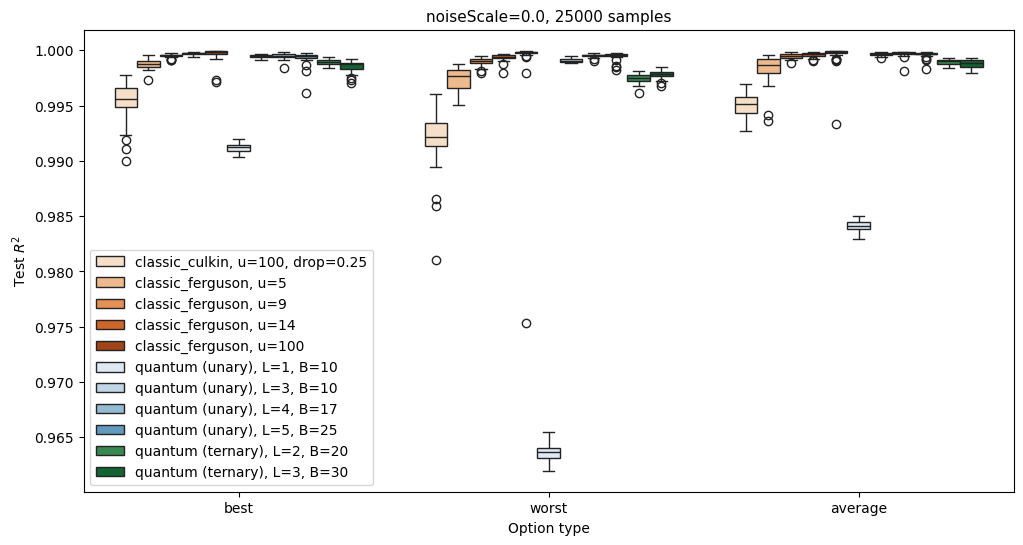

   option_type                               hue    median      mean       std
0      average  classic_culkin, u=100, drop=0.25  0.995118  0.994985  0.001079
1      average             classic_ferguson, u=5  0.998705  0.963884  0.185388
2      average             classic_ferguson, u=9  0.999462  0.999467  0.000213
3      average            classic_ferguson, u=14  0.999678  0.999616  0.000209
4      average           classic_ferguson, u=100  0.999832  0.999537  0.001196
5      average        quantum (unary), L=1, B=10  0.984067  0.984110  0.000537
6      average        quantum (unary), L=3, B=10  0.999648  0.999633  0.000127
7      average        quantum (unary), L=4, B=17  0.999719  0.999656  0.000315
8      average        quantum (unary), L=5, B=25  0.999687  0.999615  0.000294
9      average      quantum (ternary), L=2, B=20  0.998996  0.998965  0.000239
10     average      quantum (ternary), L=3, B=30  0.998857  0.998804  0.000370
11        best  classic_culkin, u=100, drop=0.25  0.

In [13]:
# ------------------------------------------------------------
# 4) Performance across option types (fixed noiseScale and n_samples)
# ------------------------------------------------------------
# User controls:
#   noise_value : selects which noiseScale setting to analyze
#   n_samples   : selects the training dataset size
#   save_as     : set to a filename (without ".pdf") to save, else None
# ------------------------------------------------------------
noise_value = 0.0               
n_samples = 25000
save_as = None
split_mode = "random"           # "time" or "random"

# Filter to comparable runs (same noise + same dataset size)
d_box = df_all.loc[
    (df_all["noiseScale"] == noise_value)
    &(df_all["n_samples"] == n_samples)
    &(df_all["split_mode"] == split_mode)
    # &(df_all["option_type"] == "best")
    # &(df_all["encoding_base"] != 3) #For unary encoding only
    # &(df_all["units"] != 14)
].copy()

# Only keep hue labels that appear in this subset (avoids empty legend entries)
hue_order_box = hue_order_for(d_box, hue_order)

# Boxplot: distribution of test R² across seeds, grouped by option type and model
_ = boxplot_metric(
    df=d_box,
    x="option_type",
    y="test_r2",
    hue="hue",
    hue_order=hue_order_box,
    palette=palette,
    title=f"noiseScale={noise_value}, {n_samples} samples",
    xlabel="Option type",
    ylabel="Test $R^2$",
    group_cols=["option_type", "hue"],
    save_as=save_as,
)

# Summary table: median/mean/std across seeds per group
summary_stats = (
    d_box.groupby(["option_type", "hue"], observed=True)["test_r2"]
         .agg(["median", "mean", "std"])
         .reset_index()
)
print(summary_stats)

## 5. Performance Across Noise Levels (Fixed Option Type and Sample Size)

fix the option type (e.g. `"worst"`) and sample size,
and analyze how the test \(R^2\) changes as `noiseScale` increases.

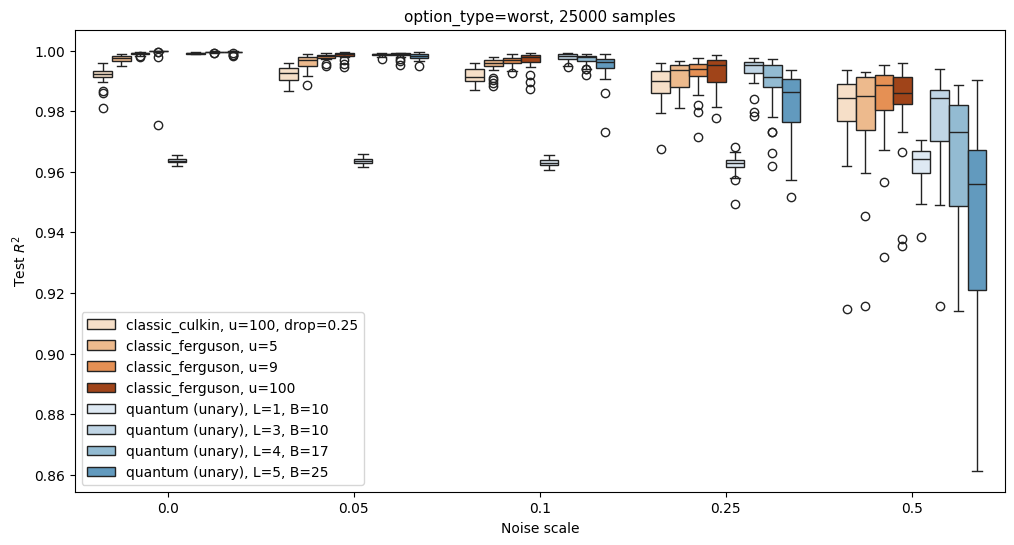

    noiseScale                               hue    median      mean       std
0         0.00  classic_culkin, u=100, drop=0.25  0.992200  0.991866  0.002978
1         0.00             classic_ferguson, u=5  0.997694  0.964210  0.182114
2         0.00             classic_ferguson, u=9  0.999069  0.998988  0.000371
3         0.00           classic_ferguson, u=100  0.999857  0.998933  0.004471
4         0.00        quantum (unary), L=1, B=10  0.963672  0.963612  0.000778
5         0.00        quantum (unary), L=3, B=10  0.999055  0.999094  0.000172
6         0.00        quantum (unary), L=4, B=17  0.999533  0.999515  0.000153
7         0.00        quantum (unary), L=5, B=25  0.999584  0.999467  0.000368
8         0.05  classic_culkin, u=100, drop=0.25  0.992633  0.992216  0.002342
9         0.05             classic_ferguson, u=5  0.996980  0.996100  0.002370
10        0.05             classic_ferguson, u=9  0.998174  0.997999  0.000909
11        0.05           classic_ferguson, u=100  0.

In [6]:
# ------------------------------------------------------------
# 5) Performance across noise levels (fixed option_type and n_samples)
# ------------------------------------------------------------
# User controls:
#   option_type : selects which basket payoff definition to analyze
#   n_samples   : selects the training dataset size
#   whisker_k   : loosen/tighten robust y-limits (higher => wider y-range)
#   save_as     : set to a filename (without ".pdf") to save, else None
# ------------------------------------------------------------
option_type = "worst"
n_samples = 25000
whisker_k = 1.5
split_mode = "random"
save_as = None


# Filter to comparable runs (same option_type + same dataset size)
d_box = df_all.loc[
    (df_all["option_type"] == option_type)
    &(df_all["n_samples"] == n_samples)
    &(df_all["split_mode"] == split_mode)
    &(df_all["encoding_base"] != 3) 
    &(df_all["units"] != 14)
].copy()

hue_order_box = hue_order_for(d_box, hue_order)

# Boxplot: distribution of test R2 across seeds, grouped by noiseScale and model
_ = boxplot_metric(
    df=d_box,
    x="noiseScale",
    y="test_r2",
    hue="hue",
    hue_order=hue_order_box,
    palette=palette,
    title=f"option_type={option_type}, {n_samples} samples",
    xlabel="Noise scale",
    ylabel="Test $R^2$",
    group_cols=["noiseScale", "hue"],
    whisker_k=whisker_k,
    save_as=save_as,
)

summary_stats = (
    d_box.groupby(["noiseScale", "hue"], observed=True)["test_r2"]
         .agg(["median", "mean", "std"])
         .reset_index()
)
print(summary_stats)

## 6. Sample Efficiency (Median Test \(R^2\) vs Number of Samples)

For a fixed option type and noise level,
compute the **median test \(R^2\)** across seeds for different training set sizes.

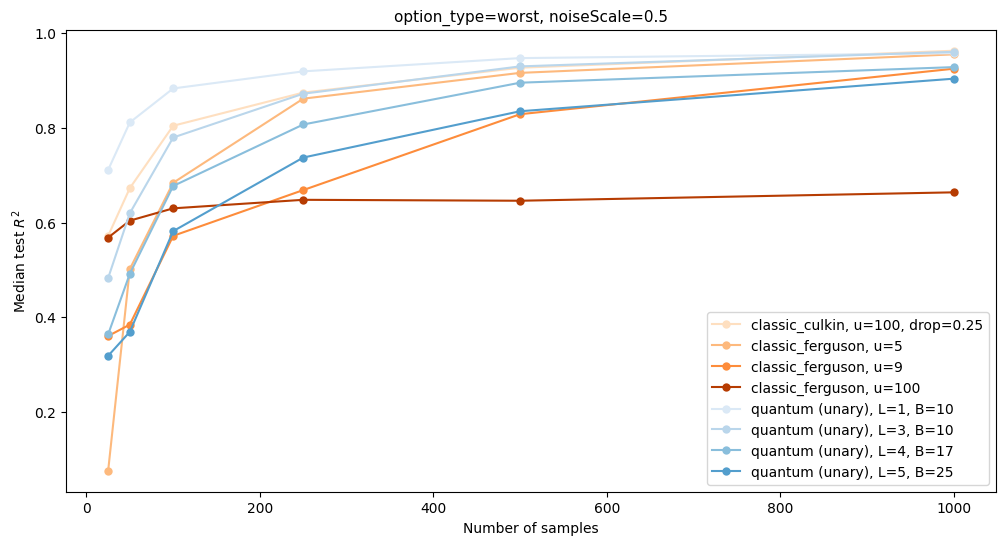

    n_samples                               hue    median
0          25  classic_culkin, u=100, drop=0.25  0.572142
1          25             classic_ferguson, u=5  0.075928
2          25             classic_ferguson, u=9  0.360517
3          25           classic_ferguson, u=100  0.568362
4          25        quantum (unary), L=1, B=10  0.711416
5          25        quantum (unary), L=3, B=10  0.482934
6          25        quantum (unary), L=4, B=17  0.363907
7          25        quantum (unary), L=5, B=25  0.318712
8          50  classic_culkin, u=100, drop=0.25  0.672921
9          50             classic_ferguson, u=5  0.502112
10         50             classic_ferguson, u=9  0.384585
11         50           classic_ferguson, u=100  0.604195
12         50        quantum (unary), L=1, B=10  0.811643
13         50        quantum (unary), L=3, B=10  0.619919
14         50        quantum (unary), L=4, B=17  0.492125
15         50        quantum (unary), L=5, B=25  0.369359
16        100 

In [7]:
# ------------------------------------------------------------
# 6) Sample efficiency: median test R2 vs number of samples
# ------------------------------------------------------------
# User controls:
#   noise_value : fixed noiseScale
#   option_type : fixed option type
#   max_samples : limit x-axis range for readability
#   save_as     : set to a filename (without ".pdf") to save, else None
# ------------------------------------------------------------
noise_value = 0.5
option_type = "worst"
max_samples = 3000
split_mode = "random"
save_as = None

# Filter and aggregate median test R2 across seeds
d_line = df_all.loc[
    (df_all["noiseScale"] == noise_value)
    &(df_all["option_type"] == option_type)
    &(df_all["split_mode"] == split_mode)
    &(df_all["n_samples"] <= max_samples)
    &(df_all["encoding_base"] != 3) 
    &(df_all["units"] != 14)
].copy()

mean_df = (
    d_line.groupby(["n_samples", "hue"], as_index=False, observed=True)["test_r2"]
          .median()
)

hue_order_line = hue_order_for(mean_df, hue_order)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=mean_df,
    x="n_samples",
    y="test_r2",
    hue="hue",
    hue_order=hue_order_line,
    palette=palette,
    marker="o",
    markeredgewidth=0,
    ax=ax,
)

# Set a tight y-range around the observed values
yvals = mean_df["test_r2"].dropna().to_numpy()
low, high = yvals.min(), yvals.max()
rng = high - low
pad = max(0.05 * rng, 0.02) if rng > 0 else 0.02
ax.set_ylim(low - pad, high + pad)

finish(
    ax,
    xlabel="Number of samples",
    ylabel="Median test $R^2$",
    title=f"option_type={option_type}, noiseScale={noise_value}",
    legend=True,
)

savefig_if(save_as)
plt.show()

summary_stats = (
    d_line.groupby(["n_samples", "hue"], observed=True)["test_r2"]
         .agg(["median"])
         .reset_index()
)
print(summary_stats)

## 7. Training Dynamics (Mean Loss Curve)

If `cost_history` is stored, we unpack it and compute the **mean loss trajectory**
across runs (grouped by model configuration).
The y-axis is plotted on a log scale to make convergence behavior easier to see.

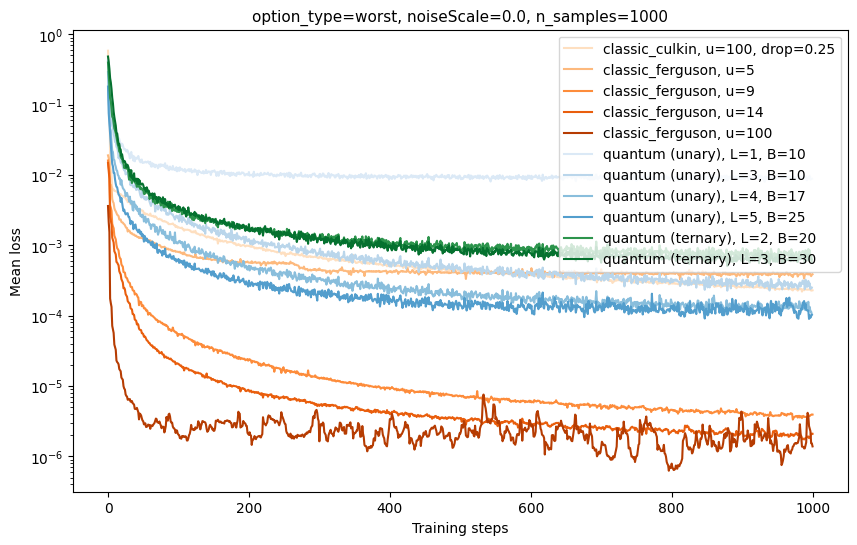

In [8]:
# ------------------------------------------------------------
# 7) Training dynamics: mean loss curve (requires cost_history)
# ------------------------------------------------------------
# User controls:
#   noise_value : fixed noiseScale
#   option_type : fixed option type
#   n_samples   : fixed dataset size
#   save_as     : set to a filename (without ".pdf") to save, else None
# ------------------------------------------------------------
noise_value = 0.0
option_type = "worst"
n_samples = 1000
split_mode = "random"
save_as = None

df_plot = df_all.loc[
    (df_all["noiseScale"] == noise_value) &
    (df_all["option_type"] == option_type) &
    (df_all["n_samples"] == n_samples)
    &(df_all["split_mode"] == split_mode)
].copy()

# Unpack cost_history (dict with arrays/lists) into tabular format
df_plot = df_plot.reset_index(drop=True)
tmp = pd.json_normalize(df_plot["cost_history"])[["steps", "loss"]]

df_plot = pd.concat([df_plot.drop(columns=["cost_history"]), tmp], axis=1)
df_plot = df_plot.explode(["steps", "loss"], ignore_index=False).dropna(subset=["steps", "loss"])

# Ensure numeric types (drop broken entries)
df_plot["steps"] = pd.to_numeric(df_plot["steps"], errors="coerce").astype("Int64")
df_plot["loss"] = pd.to_numeric(df_plot["loss"], errors="coerce")
df_plot = df_plot.dropna(subset=["steps", "loss"])

# Create a run identifier so we can average curves across multiple seeds/runs
df_plot["run_id"] = df_plot.groupby(level=0).ngroup()
df_plot["epoch"] = df_plot.groupby("run_id").cumcount()

df_plot["hue"] = pd.Categorical(df_plot["hue"], categories=hue_order, ordered=True)

# Mean curve per model configuration (averaged across runs)
df_mean = (
    df_plot.groupby(["hue", "epoch"], as_index=False, observed=True)
           .agg(mean_cost=("loss", "mean"))
)

hue_order_loss = hue_order_for(df_mean, hue_order)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df_mean,
    x="epoch",
    y="mean_cost",
    hue="hue",
    hue_order=hue_order_loss,
    palette=palette,
    ax=ax,
)

# Log-scale
ax.set_yscale("log")

finish(
    ax,
    xlabel="Training steps",
    ylabel="Mean loss",
    title=f"option_type={option_type}, noiseScale={noise_value}, n_samples={n_samples}",
    legend=True,
)

savefig_if(save_as)
plt.show()

## 8. Predictions versus target values

To compare models more directly, we can select one seed and extract:

- one classical model run
- one quantum model run

We then:
- reload both models from disk,
- recompute predictions,
- and compare scatter plots (predicted vs true) side-by-side.

Data loaded from /Users/moritzmaier/Uni/Basket-Option-Pricing-with-Quantum-Circuits/data/processed/IBM_NKE_2000-01-01_2025-01-01_win21_mat63.pkl
Data loaded from /Users/moritzmaier/Uni/Basket-Option-Pricing-with-Quantum-Circuits/data/processed/IBM_NKE_2000-01-01_2025-01-01_win21_mat63.pkl
Recomputed test R2 | Classic: 0.999384
Recomputed test R2 | Quantum: 0.999557
Stored test R2     | Classic: 0.999384
Stored test R2     | Quantum: 0.999557


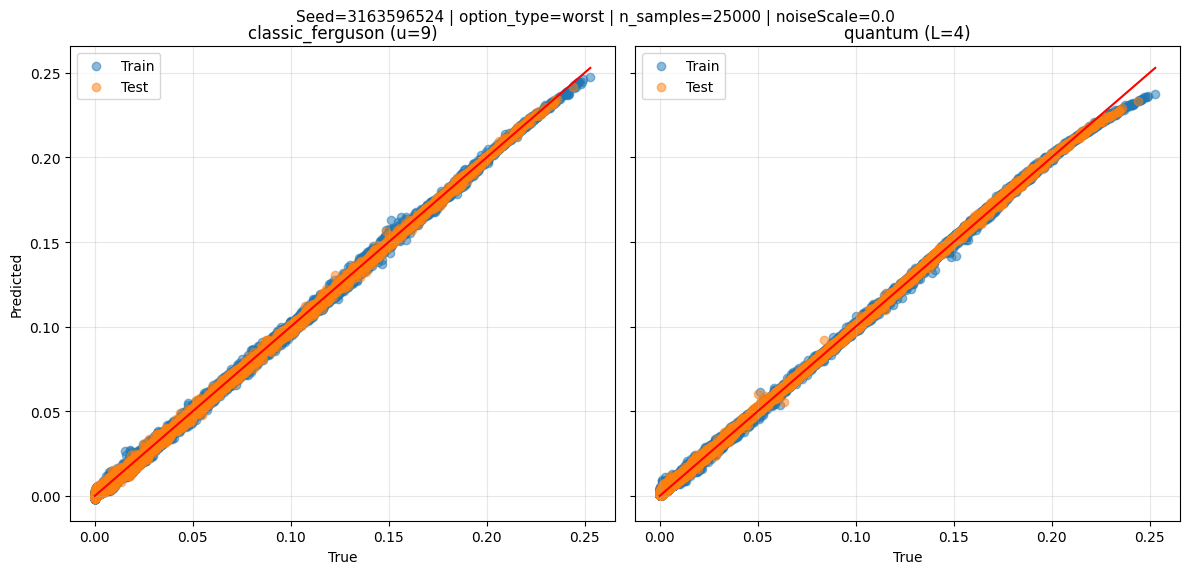

In [9]:
# ------------------------------------------------------------
# Select a matched pair (Classic vs Quantum) for the same seed
# and compare prediction quality on train/test.
# ------------------------------------------------------------

# ---------------------------
# User controls
# ---------------------------
noise_value = 0.0
option_type = "worst"
n_samples = 25000
split_mode = "random"

u = 9              # Classic Ferguson: number of units
L = 4                  # Quantum: number of layers
seed_index = 22        # Choose which seed to inspect (index into sorted unique seeds)

classic_model = "classic_ferguson"  # explizit wählen
save_as = None             # e.g. "pair_scatter_best_seed22"

# ---------------------------
# Filter results to the subset we want to compare
# ---------------------------
d_box = df_all.loc[
    (df_all["option_type"] == option_type)
    & (df_all["noiseScale"] == noise_value)
    & (df_all["n_samples"] == n_samples)
    &(df_all["split_mode"] == split_mode)
    & (
        ((df_all["model"] == "quantum") & (df_all["layers"] == L))
        | ((df_all["model"] == classic_model) & (df_all["units"] == u))
    )
].copy()

# Sanity check: make sure we actually have data after filtering
if d_box.empty:
    raise ValueError("No runs found for the given filter settings. Check your parameters.")

# ---------------------------
# Pick one seed (robustly)
# ---------------------------
unique_seeds = sorted(d_box["seed"].unique())
if not unique_seeds:
    raise ValueError("No seeds found after filtering.")

if seed_index < 0 or seed_index >= len(unique_seeds):
    raise IndexError(
        f"seed_index={seed_index} out of range. "
        f"Available seeds: 0..{len(unique_seeds)-1}"
    )

seed_value = unique_seeds[seed_index]

# Keep only runs for this seed
pair = d_box[d_box["seed"] == seed_value].copy()


# ---------------------------
# Extract one classic and one quantum Result object
# ---------------------------
def pick_result(df: pd.DataFrame, model_name: str) -> Result:
    """Pick the first Result object for a given model_name from a filtered DataFrame."""
    sub = df.loc[df["model"] == model_name, "result_obj"]
    if sub.empty:
        available = sorted(df["model"].unique().tolist())
        raise ValueError(f"Missing model '{model_name}' for seed={seed_value}. Available: {available}")
    return sub.iloc[0]

classic_result: Result = pick_result(pair, classic_model)
quantum_result: Result = pick_result(pair, "quantum")


# ---------------------------
# Recompute predictions from stored weights (no side-effects on Result)
# ---------------------------
from src.run.result_repository import reload_model
from src.visualize.metrics import get_metrics

def get_predictions_from_result(result: Result):
    """
    Reload the model + data split from params, set the stored weights,
    fit scalers (if needed), and return predictions for train/test.
    """
    model, x_train, x_test, y_train, y_test = reload_model(result)

    # Convert weights safely without mutating result.weights
    weights = [np.array(w) for w in result.weights]

    # Ensure scalers are fitted exactly as during training (if model uses scaling)
    model.fit_scaler(x_train, y_train)

    pred_train = model.get_predictions(weights=weights, x=x_train)
    pred_test  = model.get_predictions(weights=weights, x=x_test)

    return x_train, x_test, y_train, y_test, pred_train, pred_test

xtr_c, xte_c, ytr_c, yte_c, ptr_c, pte_c = get_predictions_from_result(classic_result)
xtr_q, xte_q, ytr_q, yte_q, ptr_q, pte_q = get_predictions_from_result(quantum_result)

# ---------------------------
# Metrics: recomputed (should match stored metrics up to numerical noise)
# ---------------------------
metrics_c = get_metrics(ytr_c, ptr_c, yte_c, pte_c)
metrics_q = get_metrics(ytr_q, ptr_q, yte_q, pte_q)

print(f"Recomputed test R2 | Classic: {metrics_c['test']['r2']:.6f}")
print(f"Recomputed test R2 | Quantum: {metrics_q['test']['r2']:.6f}")

print(f"Stored test R2     | Classic: {classic_result.metrics['test']['r2']:.6f}")
print(f"Stored test R2     | Quantum: {quantum_result.metrics['test']['r2']:.6f}")


# ---------------------------
# Scatter plots: predicted vs true
# ---------------------------
# Use common axis limits for fair visual comparison
min_val = min(ytr_c.min(), yte_c.min(), ytr_q.min(), yte_q.min())
max_val = max(ytr_c.max(), yte_c.max(), ytr_q.max(), yte_q.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# --- Classic ---
ax0 = axes[0]
ax0.scatter(ytr_c, ptr_c, alpha=0.5, label="Train")
ax0.scatter(yte_c, pte_c, alpha=0.5, label="Test")
ax0.plot([min_val, max_val], [min_val, max_val], color="red")
classic_model_name= classic_result.params.model_params.model_name
ax0.set_title(f"{classic_model_name} (u={u})")
ax0.set_xlabel("True")
ax0.set_ylabel("Predicted")
ax0.grid(True, alpha=0.3)
ax0.legend()

# --- Quantum ---
ax1 = axes[1]
ax1.scatter(ytr_q, ptr_q, alpha=0.5, label="Train")
ax1.scatter(yte_q, pte_q, alpha=0.5, label="Test")
ax1.plot([min_val, max_val], [min_val, max_val], color="red")
quantum_model_name= quantum_result.params.model_params.model_name
ax1.set_title(f"{quantum_model_name} (L={L})")
ax1.set_xlabel("True")
ax1.grid(True, alpha=0.3)
ax1.legend()

subtitle = (
    f"Seed={seed_value} | option_type={option_type} | "
    f"n_samples={n_samples} | noiseScale={noise_value}"
)
fig.text(0.5, 0.93, subtitle, ha="center", fontsize=11)

plt.tight_layout(rect=(0, 0, 1, 0.95))
savefig_if(save_as)
plt.show()


## 9. Error analysis 

We analyze prediction errors in feature space:

- error vs strike
- heatmap of error over volatilities


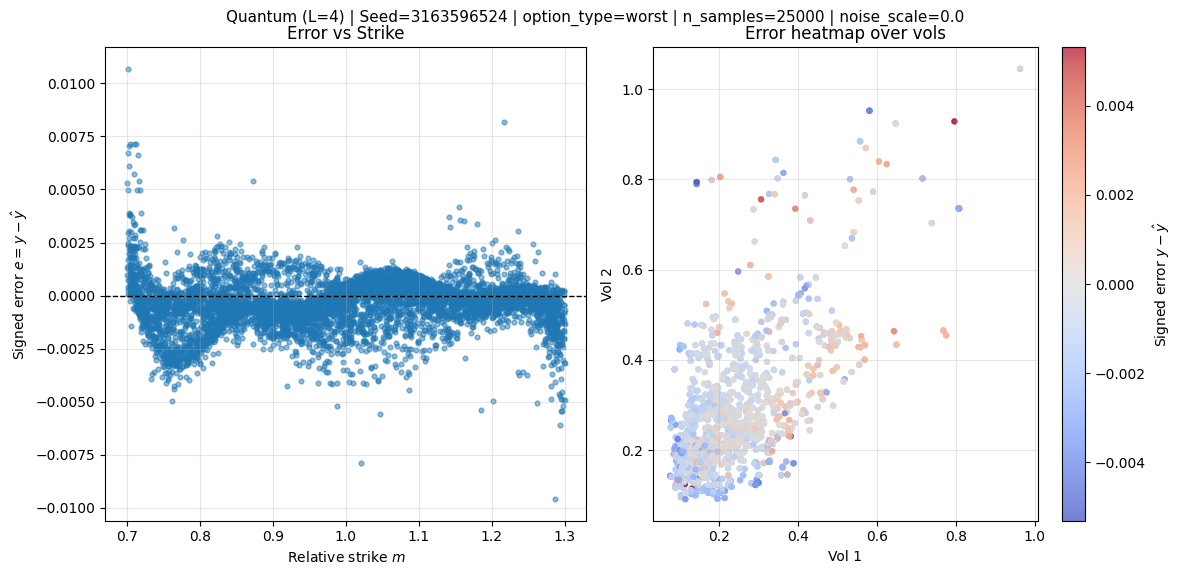

In [10]:
# ---------------------------
# User controls
# ---------------------------
model_name = "quantum"     # "classic" or "quantum"
save_as = None
vol1_idx, vol2_idx = 0, 1
strike_idx = -1
robust_q = 0.997            # quantile for robust color scaling (gnore extreme outliers)

# --- Select data ---
if model_name == "quantum":
    xte, yte, pte = xte_q, yte_q, pte_q
    title_model = f"Quantum (L={L})"
else:
    xte, yte, pte = xte_c, yte_c, pte_c
    title_model = f"Classic Ferguson (u={u})"

# --- Basic safety checks ---
n_feat = xte.shape[1]
assert 0 <= vol1_idx < n_feat and 0 <= vol2_idx < n_feat and -n_feat <= strike_idx < n_feat

# --- Extract features ---
vol1 = xte[:, vol1_idx]
vol2 = xte[:, vol2_idx]
strike = xte[:, strike_idx]

# signed error (keep sign to see bias)
error = (yte - pte).ravel()

# robust symmetric color limits to avoid outlier-dominated scaling
max_abs = np.quantile(np.abs(error), robust_q)
max_abs = max(max_abs, 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# -------- Left: Error vs Strike --------
ax0 = axes[0]
ax0.scatter(strike, error, alpha=0.5, s=12, rasterized=True)
ax0.axhline(0, color="black", linestyle="--", linewidth=1)
ax0.set_xlabel(r"Relative strike $m$")
ax0.set_ylabel(r"Signed error $e = y - \hat{y}$")
ax0.set_title("Error vs Strike")
ax0.grid(True, alpha=0.3)

# -------- Right: Error over vol-space --------
ax1 = axes[1]
sc = ax1.scatter(
    vol1, vol2,
    c=error,
    cmap="coolwarm",
    vmin=-max_abs, vmax=max_abs,
    alpha=0.7,
    s=12,
    rasterized=True,
)

cbar = fig.colorbar(sc, ax=ax1)
cbar.set_label(r"Signed error $y-\hat{y}$")

ax1.set_xlabel("Vol 1")
ax1.set_ylabel("Vol 2")
ax1.set_title("Error heatmap over vols")
ax1.grid(True, alpha=0.3)

subtitle = (
    f"{title_model} | Seed={seed_value} | option_type={option_type} | "
    f"n_samples={n_samples} | noise_scale={noise_value}"
)
fig.text(0.5, 0.93, subtitle, ha="center", fontsize=11)

plt.tight_layout(rect=(0, 0, 1, 0.95))
if save_as is not None:
    plt.savefig(f"{save_as}.pdf", bbox_inches="tight")
plt.show()

## 10. Mark High-Error Days on Rolling Volatility Time Series

Finally, we map high-error samples back to **calendar dates** and mark these
dates on the rolling volatility curves.

This can reveal whether errors cluster around regimes with unusual volatility
behavior (e.g. crisis periods).

> Note: this mapping assumes a time-based interpretation of the test window.
If the dataset split is random, this “date mapping” is less meaningful.

Data loaded from /Users/moritzmaier/Uni/Basket-Option-Pricing-with-Quantum-Circuits/data/processed/IBM_NKE_2000-01-01_2025-01-01_win21_mat63.pkl
N_days=6268 | strikes_per_day=5 | split_mode=random | test_days=1254
MODEL=quantum | marked_days=0 | threshold=0.2 | rule=any


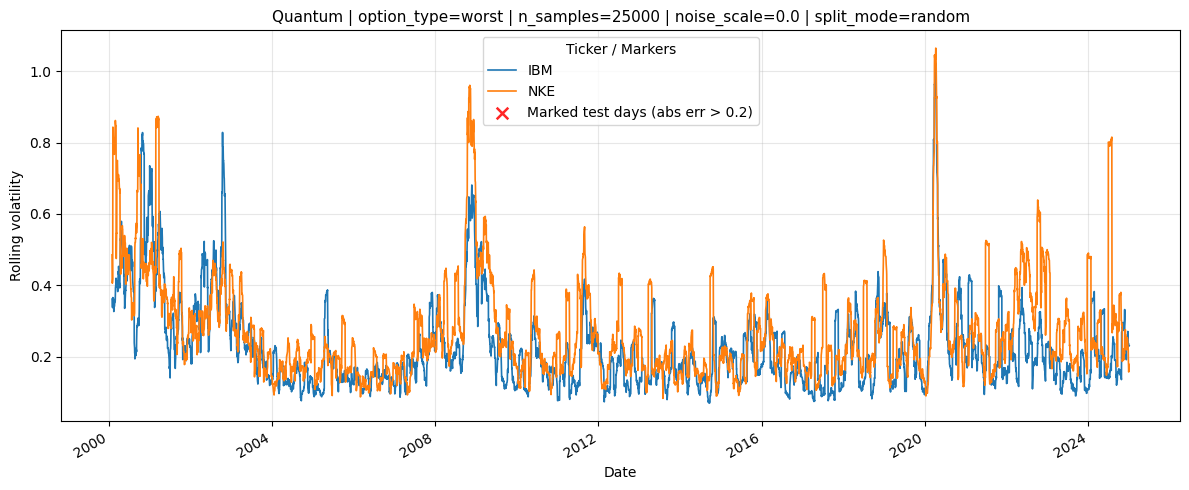

In [11]:
# ---------------------------
# User controls
# ---------------------------
MODEL = "quantum"            # "classic" or "quantum"

# Error thresholding
ERR_THR = 0.2                # absolute error threshold (used if USE_QUANTILE_THR=False)
USE_QUANTILE_THR = False     # if True: threshold = ERR_Q-quantile of abs errors
ERR_Q = 0.95                 # quantile for threshold, e.g. 0.95 => top 5% largest errors

# How to aggregate strike-level errors into a day-level flag
DAY_RULE = "any"             # "any", "max", or "mean"

# reduce clutter by only marking the worst K days
TOP_K_DAYS = None            # e.g. 30, or None for all

# Plot controls
TRAIN_MARK = True            # draw train/test split line (only meaningful for time split)
save_as = None              # e.g. "marked_vol_days_quantum"

# ------------------------------------------------------------
# Provide BOTH results (classic + quantum) from earlier pair selection
# ------------------------------------------------------------
result_map: dict[str, Result] = {
    "classic": classic_result,
    "quantum": quantum_result,
}

if MODEL.lower() not in result_map:
    raise ValueError(f"MODEL must be one of {list(result_map.keys())}")

result: Result = result_map[MODEL.lower()]

# ------------------------------------------------------------
# Load the dataset belonging to the selected Result
# ------------------------------------------------------------
dm = DataManager()
dataParams = result.params.data

data: Data = dm.load_by_params(
    dataParams.tickers,
    dataParams.start_date,
    dataParams.end_date,
    dataParams.window,
    dataParams.maturity,
)

# ------------------------------------------------------------
# Recreate the EXACT train/test split used by this Result
# ------------------------------------------------------------
mld = MLData(
    data=data,
    option_type=dataParams.option_type,
    use_percentage=dataParams.use_percentage,
    seed=result.params.seed,
    noiseScale=dataParams.noiseScale,
    split_mode=dataParams.split_mode,
)

# ------------------------------------------------------------
# Prepare rolling volatility time series
# ------------------------------------------------------------
vols = data.rolling_vols.copy()
vols.index = pd.to_datetime(vols.index)
dates = vols.index
N_days = len(dates)

# Number of strikes per day
M = int(np.asarray(data.relative_strikes).shape[1])

# ------------------------------------------------------------
# Select the correct test predictions + labels for the chosen model
# These must already exist from your earlier evaluation code.
# ------------------------------------------------------------
pred_map = {
    "classic": (pte_c, yte_c, "Classic"),
    "quantum": (pte_q, yte_q, "Quantum"),
}

pte, yte, model_title = pred_map[MODEL.lower()]
err = np.abs(np.ravel(pte) - np.ravel(yte))

# ------------------------------------------------------------
# Map test samples -> observation days via MLData indices
# ------------------------------------------------------------
obs_idx_test = np.asarray(mld.obs_idx_test)

# Sanity check: test predictions must align with the split used by MLData
if len(err) != len(obs_idx_test):
    raise ValueError(
        f"Mismatch: len(err)={len(err)} but len(obs_idx_test)={len(obs_idx_test)}. "
        "Make sure pte/yte were computed on the same split/seed as this MLData "
        f"(MODEL={MODEL}, split_mode={mld.split_mode}, seed={result.params.seed})."
    )

df_err = pd.DataFrame(
    {
        "obs_idx": obs_idx_test,
        "abs_err": err,
    }
)

# ------------------------------------------------------------
# Choose threshold and mark "bad" samples
# ------------------------------------------------------------
thr = float(df_err["abs_err"].quantile(ERR_Q)) if USE_QUANTILE_THR else float(ERR_THR)
df_err["bad_sample"] = df_err["abs_err"] > thr

# ------------------------------------------------------------
# Reduce sample-level flags to day-level flags
# ------------------------------------------------------------
if DAY_RULE == "any":
    # bad day if ANY strike-sample exceeds threshold
    bad_by_day = df_err.groupby("obs_idx")["bad_sample"].any()
elif DAY_RULE == "max":
    # bad day if max(abs_err) on that day exceeds threshold
    bad_by_day = df_err.groupby("obs_idx")["abs_err"].max() > thr
elif DAY_RULE == "mean":
    # bad day if mean(abs_err) on that day exceeds threshold
    bad_by_day = df_err.groupby("obs_idx")["abs_err"].mean() > thr
else:
    raise ValueError("DAY_RULE must be one of: 'any', 'max', 'mean'")

bad_day_idx = bad_by_day[bad_by_day].index.to_numpy()
bad_dates = dates[bad_day_idx]

# keep only TOP_K worst days (ranked by max abs error per day)
if TOP_K_DAYS is not None and len(bad_day_idx) > TOP_K_DAYS:
    day_score = df_err.groupby("obs_idx")["abs_err"].max()
    worst_idx = (
        day_score.loc[bad_day_idx]
        .sort_values(ascending=False)
        .head(TOP_K_DAYS)
        .index.to_numpy()
    )
    bad_dates = dates[worst_idx]

print(f"N_days={N_days} | strikes_per_day={M} | split_mode={mld.split_mode} | test_days={len(np.unique(obs_idx_test))}")
print(f"MODEL={MODEL} | marked_days={len(bad_dates)} | threshold={thr:.4g} | rule={DAY_RULE}")

# ------------------------------------------------------------
# Plot rolling volatilities and mark bad days (test-only)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
vols.plot(ax=ax, linewidth=1.2)

# Train/test split line ONLY makes sense for time split
if TRAIN_MARK and mld.split_mode == "time":
    split_obs_idx = int(np.min(mld.obs_idx_test))
    split_date = dates[split_obs_idx]
    ax.axvline(
        split_date,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        color="black",
        label="Train/Test split",
    )

# Mark bad days
first = True
for col in vols.columns:
    ax.scatter(
        bad_dates,
        vols.loc[bad_dates, col],
        marker="x",
        s=70,
        linewidths=1.8,
        color="red",
        alpha=0.85,
        label=f"Marked test days (abs err > {thr:.3g})" if first else None,
    )
    first = False

title = (
    f"{model_title} | option_type={dataParams.option_type} | "
    f"n_samples={dataParams.n_samples} | noise_scale={dataParams.noiseScale} | "
    f"split_mode={mld.split_mode}"
)

finish(
    ax,
    title=title,
    xlabel="Date",
    ylabel="Rolling volatility",
    legend=True,
)

ax.legend(title="Ticker / Markers")
ax.grid(True, alpha=0.3)
plt.tight_layout()

if save_as:
    plt.savefig(f"{save_as}.pdf", bbox_inches="tight")

plt.show()